# Traffic Sign Image Classification using CNN and VGG16 Transfer Learning

**Student:** Prajita Prajapati  
**ID:** 2432715  
**Module:** 6CS012 Artificial Intelligence and Machine Learning  
**Assessment Part:** Part II - Computer Vision Task


In [1]:
import os
import random
import shutil
import subprocess
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from PIL import Image, ImageFile
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import BatchNormalization, Conv2D, Dense, Dropout, Flatten, GlobalAveragePooling2D, MaxPooling2D
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.preprocessing.image import ImageDataGenerator

SEED = 42
BATCH_SIZE = 32
SCRATCH_IMAGE_SIZE = (128, 128)
TRANSFER_IMAGE_SIZE = (224, 224)
MAX_EPOCHS = 15
TRANSFER_FEATURE_EPOCHS = 8
TRANSFER_FINETUNE_EPOCHS = 7
EARLY_STOPPING_PATIENCE = 4

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
if not gpus:
    raise RuntimeError("No GPU detected. In Colab, choose Runtime > Change runtime type > T4 GPU, then run again.")

try:
    gpu_name = subprocess.check_output(
        "nvidia-smi --query-gpu=name --format=csv,noheader",
        shell=True,
        text=True
    ).strip()
    print("GPU detected:", gpu_name)
    if "T4" not in gpu_name:
        raise RuntimeError(f"Detected GPU is '{gpu_name}', not T4. Please select a T4 GPU runtime in Colab.")
except Exception as error:
    raise RuntimeError(f"Could not confirm T4 GPU using nvidia-smi: {error}")


TensorFlow version: 2.20.0
GPU detected: Tesla T4


**Result explanation:** This cell confirms the TensorFlow version and GPU type. If it stops here, change the Colab runtime to **T4 GPU** before continuing.


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


**Result explanation:** This mounts Google Drive so the notebook can read the dataset zip file from `MyDrive`.


In [3]:
# Update this path only if your zip file is stored in a different Google Drive location.
ZIP_PATH = "/content/drive/MyDrive/Traffic_Sign.zip"
EXTRACT_ROOT = Path("/content")
DATASET_ROOT = EXTRACT_ROOT / "Traffic_Sign"
ORIGINAL_TRAIN_DIR = DATASET_ROOT / "Train"
ORIGINAL_TEST_DIR = DATASET_ROOT / "Test"
SPLIT_ROOT = EXTRACT_ROOT / "Traffic_Sign_Split"
CORRUPT_QUARANTINE_DIR = EXTRACT_ROOT / "Traffic_Sign_Corrupted_Removed"

shutil.rmtree(DATASET_ROOT, ignore_errors=True)
shutil.rmtree(SPLIT_ROOT, ignore_errors=True)
shutil.rmtree(CORRUPT_QUARANTINE_DIR, ignore_errors=True)

!unzip -q "{ZIP_PATH}" -d /content/

if not ORIGINAL_TRAIN_DIR.exists():
    raise FileNotFoundError(f"Expected training folder was not found: {ORIGINAL_TRAIN_DIR}")


**Result explanation:** This extracts a fresh copy of the dataset each run. Starting fresh prevents old split folders or previous corrupted-file moves from affecting the results.


# 2.5 Part A: Designing and Analyzing CNNs from Scratch

## 2.5.1 Data Understanding, Analysis, Visualization and Cleaning

**Question:** What does the dataset represent?  
**Answer:** The dataset contains traffic sign images grouped into class folders. The task is multi-class image classification: given a traffic sign image, the model predicts the correct traffic sign category.

**Question:** How are corrupted images handled?  
**Answer:** All image files are checked using PIL before model training. Corrupted or non-image files are moved out of the active dataset directory into (/content/Traffic_Sign_Corrupted_Removed). They are removed from the dataset path but not permanently deleted from the Colab runtime.


In [4]:
ImageFile.LOAD_TRUNCATED_IMAGES = False
VALID_IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp'}
CORRUPT_QUARANTINE_DIR.mkdir(parents=True, exist_ok=True)

def clean_dataset_images(directory, quarantine_dir=CORRUPT_QUARANTINE_DIR):
    """Move corrupted/non-image files out of the active dataset directory."""
    directory = Path(directory)
    moved_files = []

    if not directory.exists():
        print(f"Skipped missing directory: {directory}")
        return moved_files

    for file_path in directory.rglob('*'):
        if not file_path.is_file():
            continue

        is_bad_file = file_path.suffix.lower() not in VALID_IMAGE_EXTENSIONS
        if not is_bad_file:
            try:
                with Image.open(file_path) as img:
                    img.verify()
                with Image.open(file_path) as img:
                    img.convert('RGB').load()
            except Exception:
                is_bad_file = True

        if is_bad_file:
            relative_path = file_path.relative_to(directory)
            destination = quarantine_dir / directory.name / relative_path
            destination.parent.mkdir(parents=True, exist_ok=True)

            counter = 1
            while destination.exists():
                destination = destination.with_name(f"{destination.stem}_{counter}{destination.suffix}")
                counter += 1

            shutil.move(str(file_path), str(destination))
            moved_files.append((str(file_path), str(destination)))

    print(f"Moved {len(moved_files)} corrupted/non-image files from {directory} to {quarantine_dir}")
    return moved_files

removed_train_files = clean_dataset_images(ORIGINAL_TRAIN_DIR)
removed_test_files = clean_dataset_images(ORIGINAL_TEST_DIR)


Moved 28 corrupted/non-image files from /content/Traffic_Sign/Train to /content/Traffic_Sign_Corrupted_Removed
Moved 0 corrupted/non-image files from /content/Traffic_Sign/Test to /content/Traffic_Sign_Corrupted_Removed


**Result explanation:** The printed count tells how many unusable files were removed from model training. If the count is greater than zero, those files are preserved in the quarantine folder for review.


### Train, Validation, and Test Split

**Question:** How is the dataset split into training and validation sets? Justify your choice.  
**Answer:** The original training directory is split class-by-class into **70% training**, **15% validation**, and **15% test**. The validation set is used for training decisions such as EarlyStopping, while the test set remains unseen until final evaluation. This is fairer than reporting only validation accuracy.


In [5]:
TRAIN_RATIO = 0.70
VALIDATION_RATIO = 0.15
TEST_RATIO = 0.15

train_dir = SPLIT_ROOT / "train"
val_dir = SPLIT_ROOT / "validation"
test_dir = SPLIT_ROOT / "test"

shutil.rmtree(SPLIT_ROOT, ignore_errors=True)
rng = random.Random(SEED)

for class_dir in sorted(ORIGINAL_TRAIN_DIR.iterdir()):
    if not class_dir.is_dir():
        continue

    image_paths = sorted([
        path for path in class_dir.iterdir()
        if path.is_file() and path.suffix.lower() in VALID_IMAGE_EXTENSIONS
    ])

    if len(image_paths) < 3:
        raise ValueError(f"Class '{class_dir.name}' has fewer than 3 usable images after cleaning.")

    rng.shuffle(image_paths)
    n_images = len(image_paths)
    n_val = max(1, round(n_images * VALIDATION_RATIO))
    n_test = max(1, round(n_images * TEST_RATIO))
    n_train = n_images - n_val - n_test

    if n_train < 1:
        n_train = 1
        if n_val > n_test:
            n_val -= 1
        else:
            n_test -= 1

    split_map = {
        "train": image_paths[:n_train],
        "validation": image_paths[n_train:n_train + n_val],
        "test": image_paths[n_train + n_val:]
    }

    for split_name, paths in split_map.items():
        destination_class_dir = SPLIT_ROOT / split_name / class_dir.name
        destination_class_dir.mkdir(parents=True, exist_ok=True)
        for src_path in paths:
            shutil.copy2(src_path, destination_class_dir / src_path.name)

print(f"Dataset split created at: {SPLIT_ROOT}")
print(f"Requested split: train={TRAIN_RATIO:.0%}, validation={VALIDATION_RATIO:.0%}, test={TEST_RATIO:.0%}")


Dataset split created at: /content/Traffic_Sign_Split
Requested split: train=70%, validation=15%, test=15%


**Result explanation:** The split is created from the cleaned training data. Each class is split separately so all classes appear in train, validation, and test whenever enough images are available.


### Dataset Size and Class Distribution

**Question:** How many total images are in the dataset?  
**Answer:** The following cell counts usable images after cleaning and splitting.

**Question:** What is the distribution of images across different classes?  
**Answer:** The class distribution is printed and visualized below. This is important because imbalanced classes can reduce recall for minority classes.


In [6]:
train_dir = str(train_dir)
val_dir = str(val_dir)
test_dir = str(test_dir)

def count_images_by_class(directory):
    class_counts = {}
    total_images = 0
    for class_name in sorted(os.listdir(directory)):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            count = sum(
                1 for file_name in os.listdir(class_path)
                if os.path.isfile(os.path.join(class_path, file_name))
            )
            class_counts[class_name] = count
            total_images += count
    return total_images, class_counts

train_total, train_class_counts = count_images_by_class(train_dir)
val_total, val_class_counts = count_images_by_class(val_dir)
test_total, test_class_counts = count_images_by_class(test_dir)
all_total = train_total + val_total + test_total

print("Total usable images:", all_total)
print("Training images:", train_total)
print("Validation images:", val_total)
print("Test images:", test_total)
print("Training class distribution:", train_class_counts)
print("Validation class distribution:", val_class_counts)
print("Test class distribution:", test_class_counts)


print("\nDataset diagnostics:")
print("Number of classes:", len(train_class_counts))
print("Smallest training class:", min(train_class_counts, key=train_class_counts.get), min(train_class_counts.values()))
print("Largest training class:", max(train_class_counts, key=train_class_counts.get), max(train_class_counts.values()))
imbalance_ratio = max(train_class_counts.values()) / min(train_class_counts.values())
print(f"Imbalance ratio (largest/smallest class): {imbalance_ratio:.2f}")

if all_total < 5000:
    print("Warning: Dataset is relatively small for deep learning; high accuracy may not generalize well.")
elif len(train_class_counts) <= 4:
    print("Note: The dataset has only a few broad classes, so very high accuracy can occur if classes are visually distinct.")

if imbalance_ratio > 1.5:
    print("Warning: The dataset is imbalanced. Class weights are recommended to reduce majority-class bias.")

print("Important: Because train/validation/test are split from the same source dataset, very high test accuracy should be validated on an external dataset before making real-world claims.")


Total usable images: 15867
Training images: 11109
Validation images: 2379
Test images: 2379
Training class distribution: {'Caution': 1696, 'Instructions': 1989, 'No Passing': 3754, 'OverSpeed': 3670}
Validation class distribution: {'Caution': 363, 'Instructions': 426, 'No Passing': 804, 'OverSpeed': 786}
Test class distribution: {'Caution': 363, 'Instructions': 426, 'No Passing': 804, 'OverSpeed': 786}

Dataset diagnostics:
Number of classes: 4
Smallest training class: Caution 1696
Largest training class: No Passing 3754
Imbalance ratio (largest/smallest class): 2.21
Note: The dataset has only a few broad classes, so very high accuracy can occur if classes are visually distinct.
Important: Because train/validation/test are split from the same source dataset, very high test accuracy should be validated on an external dataset before making real-world claims.


**Result explanation:** Use these counts to check whether the dataset is balanced. If one class has fewer images, the model may have lower recall for that class.


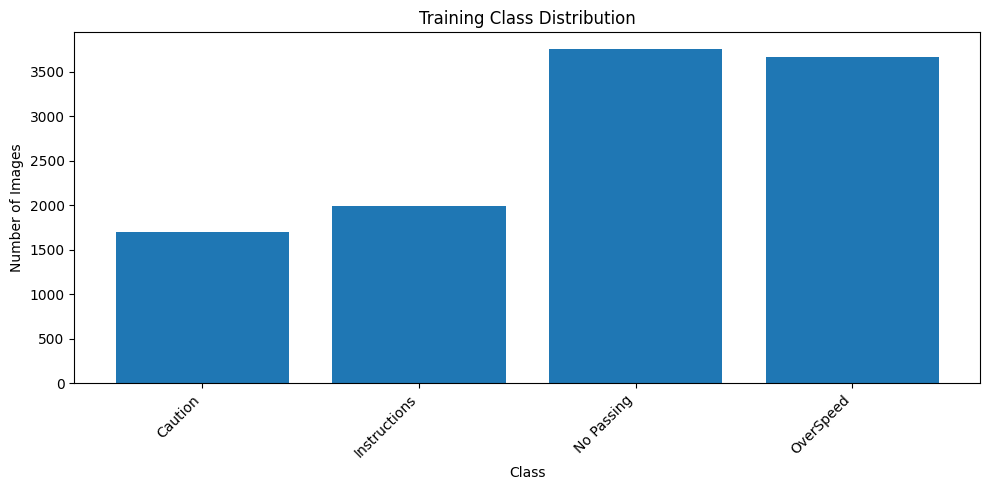

In [7]:
plt.figure(figsize=(10, 5))
plt.bar(train_class_counts.keys(), train_class_counts.values())
plt.title("Training Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Plot explanation:** This bar chart shows the number of training images per class. Large differences between bars indicate class imbalance, which can make precision or recall worse for smaller classes.


### Preprocessing and Data Generators

**Question:** What preprocessing techniques were applied?  
**Answer:** Images for CNN-from-scratch models are resized to (128 x 128), batched, and normalized to [0, 1] using (rescale=1./255).

**Question:** What data generators were used?  
**Answer:** (ImageDataGenerator) is used. The training generator applies normalization and augmentation; validation and test generators only normalize images so evaluation remains consistent.

**Question:** If data augmentation was applied, provide visualizations of sample augmented images.  
**Answer:** Rotation, zoom, and horizontal flipping are applied to the training set and visualized below.


In [8]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.25,
    width_shift_range=0.10,
    height_shift_range=0.10,
    brightness_range=(0.80, 1.20),
    horizontal_flip=True
)

eval_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=SCRATCH_IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_data = eval_datagen.flow_from_directory(
    val_dir,
    target_size=SCRATCH_IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_data = eval_datagen.flow_from_directory(
    test_dir,
    target_size=SCRATCH_IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_names = list(train_data.class_indices.keys())
num_classes = train_data.num_classes
print("Classes:", class_names)

class_weight_values = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)
class_weights = {index: weight for index, weight in enumerate(class_weight_values)}
print("Class weights used during training:", class_weights)


Found 11109 images belonging to 4 classes.
Found 2379 images belonging to 4 classes.
Found 2379 images belonging to 4 classes.
Classes: ['Caution', 'Instructions', 'No Passing', 'OverSpeed']
Class weights used during training: {0: np.float64(1.6375294811320755), 1: np.float64(1.3963046757164403), 2: np.float64(0.7398108684070325), 3: np.float64(0.7567438692098093)}


**Result explanation:** These generators load images in batches. The test generator uses `shuffle=False` so predictions match the correct filenames and confusion matrix labels. Class weights are also calculated from the training split so smaller classes receive more attention during training, which can improve class-wise recall. Horizontal flipping is included as an additional augmentation step to make the training task harder and reduce overfitting, but its effect should be discussed carefully because some traffic signs may not naturally appear flipped.


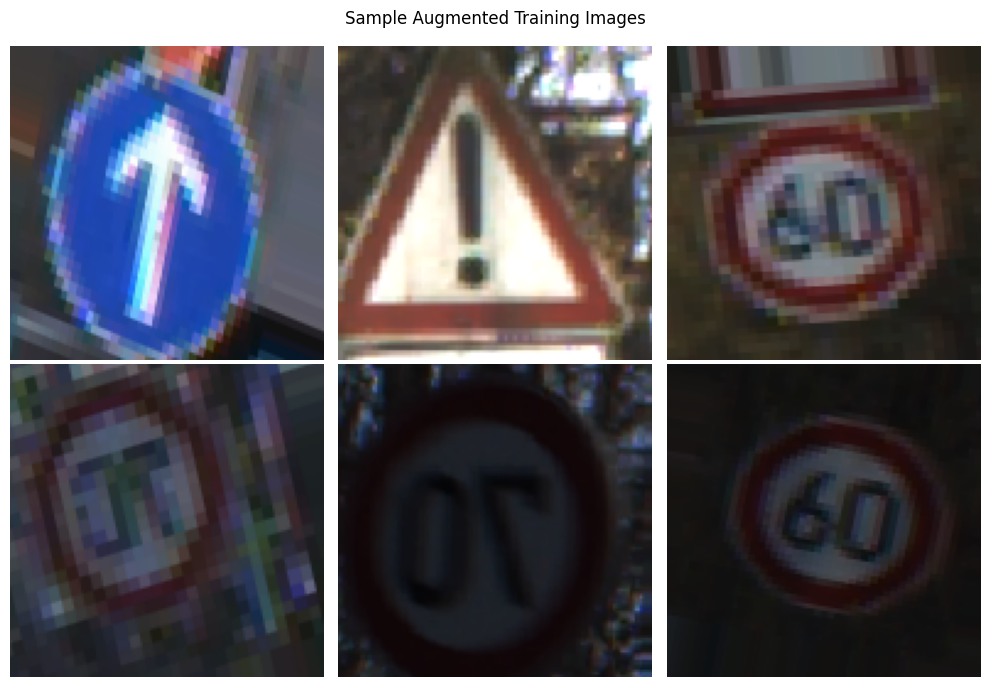

In [9]:
augmented_images, augmented_labels = next(train_data)

plt.figure(figsize=(10, 7))
for i in range(min(6, len(augmented_images))):
    plt.subplot(2, 3, i + 1)
    plt.imshow(augmented_images[i])
    plt.axis('off')
plt.suptitle("Sample Augmented Training Images")
plt.tight_layout()
plt.show()


**Plot explanation:** These images show how augmentation changes the training samples. Augmentation helps the model generalize, but it should not distort traffic signs so much that the label becomes unclear.


## Shared Training and Evaluation Helpers

All model comparisons below use the same maximum epoch count and callback settings. EarlyStopping may stop different models at different actual epochs, but every model receives the same opportunity: up to `MAX_EPOCHS = 15` with patience 4.


In [10]:
def make_callbacks(model_name):
    return [
        EarlyStopping(
            monitor='val_loss',
            patience=EARLY_STOPPING_PATIENCE,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1
        )
    ]

def plot_history(history, title, max_epochs=MAX_EPOCHS):
    epochs_run = range(1, len(history.history['loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs_run, history.history['loss'], marker='o', label='Training Loss')
    axes[0].plot(epochs_run, history.history['val_loss'], marker='o', label='Validation Loss')
    axes[0].set_title(f"{title} Loss")
    axes[0].set_xlabel("Epoch Actually Run")
    axes[0].set_ylabel("Loss")
    axes[0].set_ylim(bottom=0)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs_run, history.history['accuracy'], marker='o', label='Training Accuracy')
    axes[1].plot(epochs_run, history.history['val_accuracy'], marker='o', label='Validation Accuracy')
    axes[1].set_title(f"{title} Accuracy")
    axes[1].set_xlabel("Epoch Actually Run")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_ylim(0, 1.05)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    print(f"{title} ran for {len(history.history['loss'])} epoch(s) out of the configured maximum of {max_epochs}.")

def train_with_timer(model, train_generator, val_generator, model_name, epochs=MAX_EPOCHS, class_weight=class_weights, verbose=1):
    start_time = time.time()
    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=epochs,
        callbacks=make_callbacks(model_name),
        class_weight=class_weight,
        verbose=verbose
    )
    training_time = time.time() - start_time
    return history, training_time

def classification_report_dataframe(y_true, y_pred, class_names):
    report_dict = classification_report(
        y_true,
        y_pred,
        labels=range(len(class_names)),
        target_names=class_names,
        zero_division=0,
        output_dict=True
    )
    return pd.DataFrame(report_dict).transpose()

def plot_metric_heatmap(report_df, class_names_for_plot, title):
    class_metric_df = report_df.loc[class_names_for_plot, ['precision', 'recall', 'f1-score']]
    fig, ax = plt.subplots(figsize=(7, max(4, len(class_metric_df) * 0.45)))
    im = ax.imshow(class_metric_df.values, cmap='YlGnBu', vmin=0, vmax=1)
    ax.set_xticks(np.arange(class_metric_df.shape[1]))
    ax.set_xticklabels(class_metric_df.columns)
    ax.set_yticks(np.arange(class_metric_df.shape[0]))
    ax.set_yticklabels(class_metric_df.index)

    for row in range(class_metric_df.shape[0]):
        for col in range(class_metric_df.shape[1]):
            ax.text(col, row, f"{class_metric_df.iloc[row, col]:.2f}", ha='center', va='center', color='black')

    ax.set_title(title)
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

def plot_confusion_matrices(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))
    cm_normalized = confusion_matrix(y_true, y_pred, labels=range(len(class_names)), normalize='true')

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=axes[0], xticks_rotation=45, colorbar=False)
    axes[0].set_title(f"{title} Raw Confusion Matrix")

    ConfusionMatrixDisplay(cm_normalized, display_labels=class_names).plot(ax=axes[1], xticks_rotation=45, colorbar=False, values_format='.2f')
    axes[1].set_title(f"{title} Normalized Confusion Matrix")

    plt.tight_layout()
    plt.show()
    return cm

def evaluate_model(model, data_generator, class_names, title):
    data_generator.reset()
    loss, accuracy = model.evaluate(data_generator, verbose=0)

    data_generator.reset()
    probabilities = model.predict(data_generator, verbose=0)
    y_pred = np.argmax(probabilities, axis=1)
    y_true = data_generator.classes

    report_df = classification_report_dataframe(y_true, y_pred, class_names)
    print(f"{title} Loss: {loss:.4f}")
    print(f"{title} Accuracy: {accuracy:.4f}")
    print("Class-wise precision, recall, and F1-score:")
    print(report_df[['precision', 'recall', 'f1-score', 'support']])

    cm = plot_confusion_matrices(y_true, y_pred, class_names, title)
    plot_metric_heatmap(report_df, class_names, f"{title} Class-wise Metric Heatmap")

    class_report = report_df.loc[class_names]
    lowest_recall_class = class_report['recall'].astype(float).idxmin()
    lowest_recall_value = class_report.loc[lowest_recall_class, 'recall']
    print(f"Lowest recall class for {title}: {lowest_recall_class} ({lowest_recall_value:.4f})")

    return {
        "model": title,
        "loss": loss,
        "accuracy": accuracy,
        "y_true": y_true,
        "y_pred": y_pred,
        "probabilities": probabilities,
        "report_df": report_df,
        "confusion_matrix": cm,
        "lowest_recall_class": lowest_recall_class,
        "lowest_recall_value": lowest_recall_value
    }

def display_prediction_examples(data_generator, class_names, y_true, y_pred, title, correct=True, target_class=None, max_images=6):
    selected_indices = []
    for index, (true_label, pred_label) in enumerate(zip(y_true, y_pred)):
        condition = true_label == pred_label if correct else true_label != pred_label
        if target_class is not None:
            condition = condition and class_names[true_label] == target_class
        if condition:
            selected_indices.append(index)
        if len(selected_indices) >= max_images:
            break

    if not selected_indices:
        print(f"No {'correct' if correct else 'incorrect'} examples found for: {title}")
        return

    plt.figure(figsize=(10, 7))
    for plot_number, index in enumerate(selected_indices, start=1):
        image_path = data_generator.filepaths[index]
        image = Image.open(image_path).convert('RGB')
        plt.subplot(2, 3, plot_number)
        plt.imshow(image)
        plt.title(f"Pred: {class_names[y_pred[index]]}\nTrue: {class_names[y_true[index]]}")
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def analyze_confusions(result, class_names, title):
    cm = result['confusion_matrix'].copy()
    np.fill_diagonal(cm, 0)
    confusion_pairs = []
    for true_index in range(cm.shape[0]):
        for pred_index in range(cm.shape[1]):
            if cm[true_index, pred_index] > 0:
                confusion_pairs.append((cm[true_index, pred_index], class_names[true_index], class_names[pred_index]))
    confusion_pairs = sorted(confusion_pairs, reverse=True)[:5]

    print(f"Top confusion pairs for {title}:")
    if not confusion_pairs:
        print("No misclassifications found in this test run.")
    for count, true_class, predicted_class in confusion_pairs:
        print(f"True '{true_class}' predicted as '{predicted_class}': {count} image(s)")

    lowered_pairs = [(t.lower(), p.lower()) for _, t, p in confusion_pairs]
    if any(('instruction' in t and 'caution' in p) or ('caution' in t and 'instruction' in p) for t, p in lowered_pairs):
        print("Instruction/Caution note: these signs may share similar shapes, colors, or symbol layouts, which can reduce recall between these classes.")
    else:
        print("Instruction/Caution note: if instruction or caution recall is low, likely causes include visual similarity, class imbalance, or insufficient examples for those signs.")


**Helper explanation:** These helpers make the comparisons fair. All models use the same maximum epochs and callbacks. The graphs only plot epochs that actually ran, so a model stopped by EarlyStopping will not show misleading extra flat lines. For image classification, a raw pixel correlation heatmap is not very meaningful, so this notebook uses class-wise metric heatmaps and raw/normalized confusion matrices instead.


## 2.5.2 Design, Train, and Evaluate a Baseline Model

### Baseline Model Architecture

**Question:** Does the baseline CNN satisfy the required structure?  
**Answer:** Yes. The baseline model has three convolutional layers, each followed by max-pooling, then three fully connected layers and a softmax output layer.

**Question:** What kernel sizes, filters, and activations are used?  
**Answer:** Each convolution uses a `3 x 3` kernel with ReLU activation. Filters increase from 32 to 64 to 128. The output uses softmax for multi-class classification.


In [11]:
def build_baseline_model(input_shape=(128, 128, 3), num_classes=num_classes):
    model = Sequential(name="baseline_cnn")
    # Reduced filters to prevent overfitting
    model.add(Conv2D(16, (3, 3), activation='relu', input_shape=input_shape))
    model.add(MaxPooling2D(2, 2))

    model.add(Conv2D(32, (3, 3), activation='relu'))
    model.add(MaxPooling2D(2, 2))

    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(MaxPooling2D(2, 2))

    model.add(Flatten())
    model.add(Dropout(0.5))  # Add dropout
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))
    return model

baseline_model = build_baseline_model(num_classes=num_classes)
baseline_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
baseline_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,639,812 (6.26 MB)

 Trainable params: 1,639,812 (6.26 MB)

 Non-trainable params: 0 (0.00 B)

**Result explanation:** The summary confirms the baseline architecture required by the PDF: 3 convolutional layers, 3 fully connected layers, and a final output layer.


Epoch 1/15
348/348 ━━━━━━━━━━━━━━━━━━━━ 76s 193ms/step - accuracy: 0.7150 - loss: 0.6843 - val_accuracy: 0.9449 - val_loss: 0.1555 - learning_rate: 0.0010
Epoch 2/15
348/348 ━━━━━━━━━━━━━━━━━━━━ 63s 180ms/step - accuracy: 0.9027 - loss: 0.2851 - val_accuracy: 0.9609 - val_loss: 0.0869 - learning_rate: 0.0010
Epoch 3/15
348/348 ━━━━━━━━━━━━━━━━━━━━ 60s 172ms/step - accuracy: 0.9342 - loss: 0.1951 - val_accuracy: 0.9836 - val_loss: 0.0433 - learning_rate: 0.0010
Epoch 4/15
348/348 ━━━━━━━━━━━━━━━━━━━━ 61s 174ms/step - accuracy: 0.9518 - loss: 0.1401 - val_accuracy: 0.9899 - val_loss: 0.0258 - learning_rate: 0.0010
Epoch 5/15
348/348 ━━━━━━━━━━━━━━━━━━━━ 60s 173ms/step - accuracy: 0.9628 - loss: 0.1088 - val_accuracy: 0.9958 - val_loss: 0.0145 - learning_rate: 0.0010
Epoch 6/15
348/348 ━━━━━━━━━━━━━━━━━━━━ 60s 172ms/step - accuracy: 0.9668 - loss: 0.1000 - val_accuracy: 0.9954 - val_loss: 0.0163 - learning_rate: 0.0010
Epoch 7/15
348/348 ━━━━━━━━━━━━━━━━━━━━ 60s 171ms/step - accuracy: 0.9

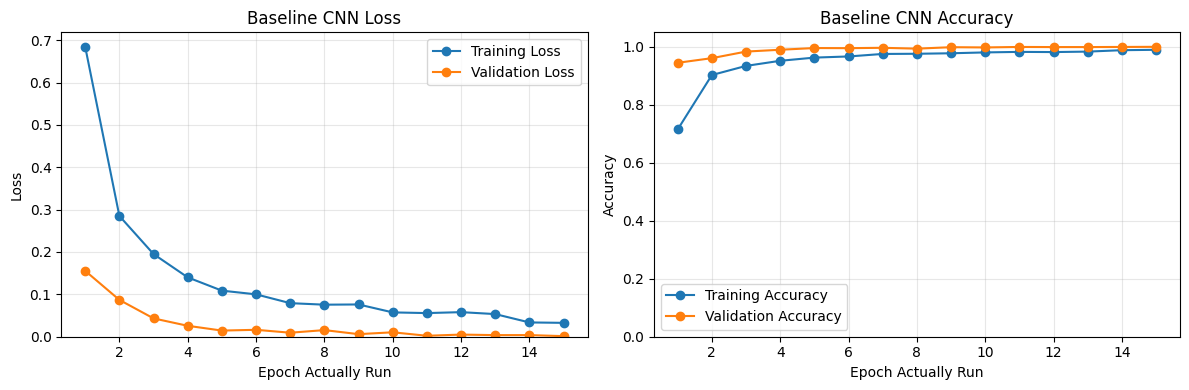

Baseline CNN ran for 15 epoch(s) out of the configured maximum of 15.


In [12]:
baseline_history, baseline_time = train_with_timer(
    baseline_model,
    train_data,
    val_data,
    "Baseline CNN",
    epochs=MAX_EPOCHS
)
print(f"Baseline training time: {baseline_time:.2f} seconds")
plot_history(baseline_history, "Baseline CNN")


**Plot/result explanation:** The baseline is trained for up to 15 epochs, but EarlyStopping with patience 4 may stop it earlier. If validation loss stops improving while training accuracy rises, that is overfitting.


Baseline CNN Test Loss: 0.0040
Baseline CNN Test Accuracy: 0.9975
Class-wise precision, recall, and F1-score:
              precision    recall  f1-score      support
Caution        0.991803  1.000000  0.995885   363.000000
Instructions   1.000000  0.990610  0.995283   426.000000
No Passing     0.997519  1.000000  0.998758   804.000000
OverSpeed      0.998726  0.997455  0.998090   786.000000
accuracy       0.997478  0.997478  0.997478     0.997478
macro avg      0.997012  0.997016  0.997004  2379.000000
weighted avg   0.997490  0.997478  0.997477  2379.000000


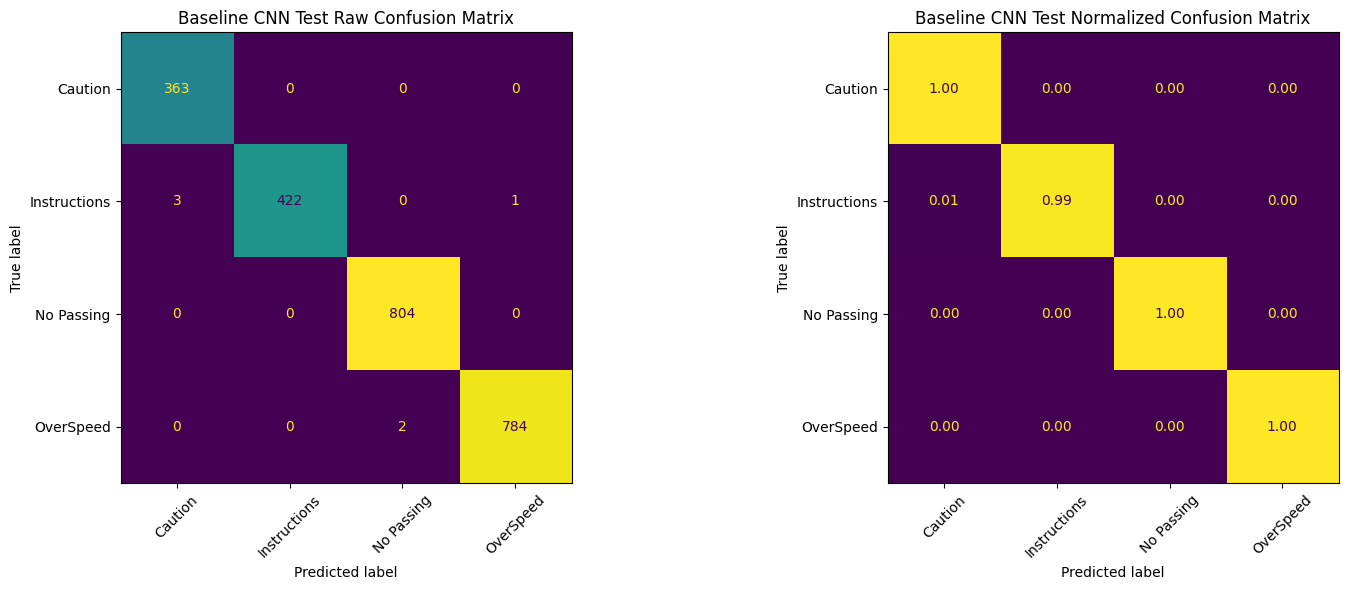

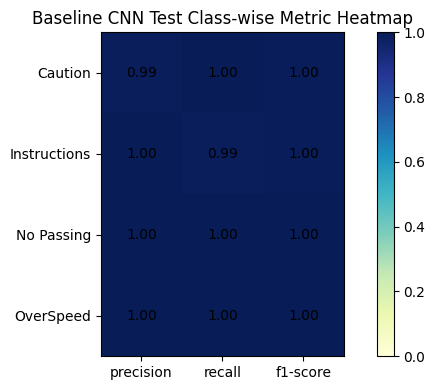

Lowest recall class for Baseline CNN Test: Instructions (0.9906)
Top confusion pairs for Baseline CNN Test:
True 'Instructions' predicted as 'Caution': 3 image(s)
True 'OverSpeed' predicted as 'No Passing': 2 image(s)
True 'Instructions' predicted as 'OverSpeed': 1 image(s)
Instruction/Caution note: these signs may share similar shapes, colors, or symbol layouts, which can reduce recall between these classes.


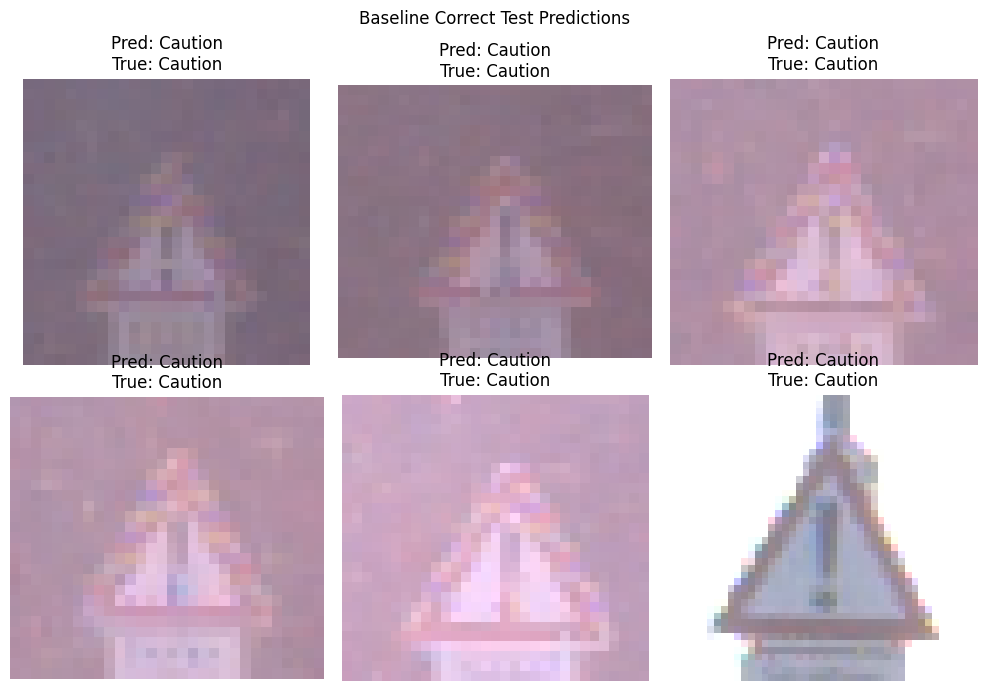

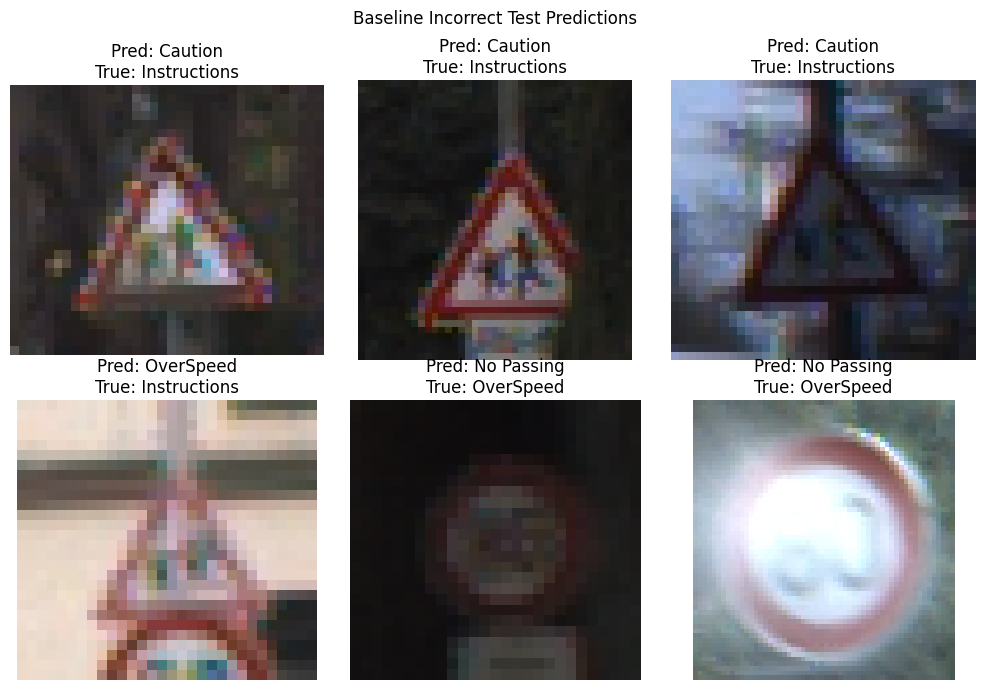

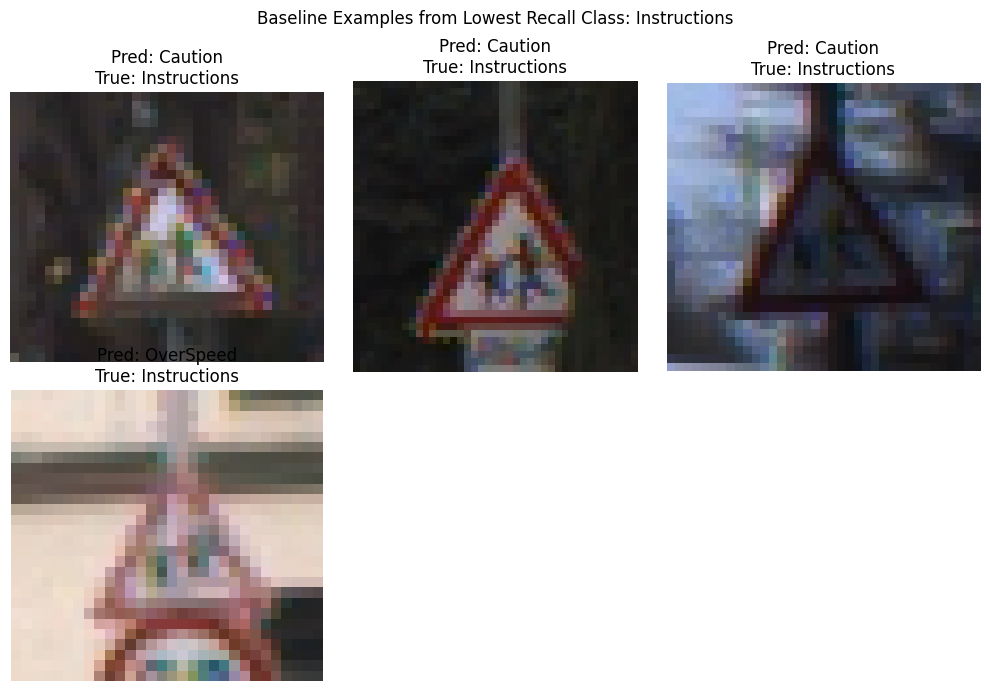

In [13]:
baseline_results = evaluate_model(baseline_model, test_data, class_names, "Baseline CNN Test")
analyze_confusions(baseline_results, class_names, "Baseline CNN Test")
display_prediction_examples(test_data, class_names, baseline_results['y_true'], baseline_results['y_pred'], "Baseline Correct Test Predictions", correct=True)
display_prediction_examples(test_data, class_names, baseline_results['y_true'], baseline_results['y_pred'], "Baseline Incorrect Test Predictions", correct=False)
display_prediction_examples(
    test_data,
    class_names,
    baseline_results['y_true'],
    baseline_results['y_pred'],
    f"Baseline Examples from Lowest Recall Class: {baseline_results['lowest_recall_class']}",
    correct=False,
    target_class=baseline_results['lowest_recall_class']
)


**Result explanation:** The first image grid shows correct examples, so it is not only an error sample. The second grid intentionally shows incorrect predictions. The final grid focuses on the lowest-recall class to explain where the model struggles. If instruction and caution signs appear in the confusion pairs, the likely reason is visual similarity between sign shapes, colors, or symbols.


## 2.5.3 Deeper Architecture with Regularization Layer

**Question:** Is the deeper model at least double the baseline model?  
**Answer:** Yes. The baseline has three convolutional layers. The deeper model has six convolutional layers.

**Question:** Which regularization techniques are introduced?  
**Answer:** Batch Normalization and Dropout are added. Batch Normalization stabilizes training; Dropout reduces overfitting.


In [14]:

def build_deep_model(input_shape=(128, 128, 3), num_classes=num_classes, use_dropout=True, optimizer='adam'):
    model = Sequential(name=f"deep_cnn_{optimizer}_{'dropout' if use_dropout else 'no_dropout'}")
    regularizer = l2(0.001)

    model.add(Conv2D(32, (3, 3), activation='relu', padding='same', kernel_regularizer=regularizer, input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same', kernel_regularizer=regularizer))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2, 2))
    if use_dropout:
        model.add(Dropout(0.40))

    model.add(Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=regularizer))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=regularizer))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2, 2))
    if use_dropout:
        model.add(Dropout(0.50))

    model.add(Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=regularizer))
    model.add(BatchNormalization())
    model.add(Conv2D(256, (3, 3), activation='relu', padding='same', kernel_regularizer=regularizer))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2, 2))
    if use_dropout:
        model.add(Dropout(0.50))

    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    if use_dropout:
        model.add(Dropout(0.50))
    model.add(Dense(128, activation='relu'))
    if use_dropout:
        model.add(Dropout(0.50))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))

    selected_optimizer = SGD(learning_rate=0.001, momentum=0.9) if optimizer == 'sgd' else Adam(learning_rate=0.001)
    model.compile(
        optimizer=selected_optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

deep_model = build_deep_model(num_classes=num_classes, use_dropout=True, optimizer='adam')
deep_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "deep_cnn_adam_dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │    16,777,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,89

 Total params: 17,255,780 (65.83 MB)

 Trainable params: 17,254,628 (65.82 MB)

 Non-trainable params: 1,152 (4.50 KB)

**Result explanation:** The deeper model summary confirms six convolutional layers and the use of Batch Normalization and Dropout. This satisfies the PDF requirement for a deeper regularized architecture.


Epoch 1/15
348/348 ━━━━━━━━━━━━━━━━━━━━ 108s 249ms/step - accuracy: 0.3928 - loss: 4.2693 - val_accuracy: 0.4103 - val_loss: 1.7186 - learning_rate: 0.0010
Epoch 2/15
348/348 ━━━━━━━━━━━━━━━━━━━━ 72s 205ms/step - accuracy: 0.5883 - loss: 1.3872 - val_accuracy: 0.7024 - val_loss: 1.1666 - learning_rate: 0.0010
Epoch 3/15
348/348 ━━━━━━━━━━━━━━━━━━━━ 68s 195ms/step - accuracy: 0.5995 - loss: 1.2510 - val_accuracy: 0.8680 - val_loss: 0.6777 - learning_rate: 0.0010
Epoch 4/15
348/348 ━━━━━━━━━━━━━━━━━━━━ 67s 191ms/step - accuracy: 0.6496 - loss: 1.0713 - val_accuracy: 0.8138 - val_loss: 0.8199 - learning_rate: 0.0010
Epoch 5/15
348/348 ━━━━━━━━━━━━━━━━━━━━ 67s 193ms/step - accuracy: 0.7356 - loss: 0.9163 - val_accuracy: 0.9420 - val_loss: 0.4414 - learning_rate: 0.0010
Epoch 6/15
348/348 ━━━━━━━━━━━━━━━━━━━━ 67s 192ms/step - accuracy: 0.7743 - loss: 0.8287 - val_accuracy: 0.7545 - val_loss: 0.9598 - learning_rate: 0.0010
Epoch 7/15
348/348 ━━━━━━━━━━━━━━━━━━━━ 65s 187ms/step - accuracy: 0.

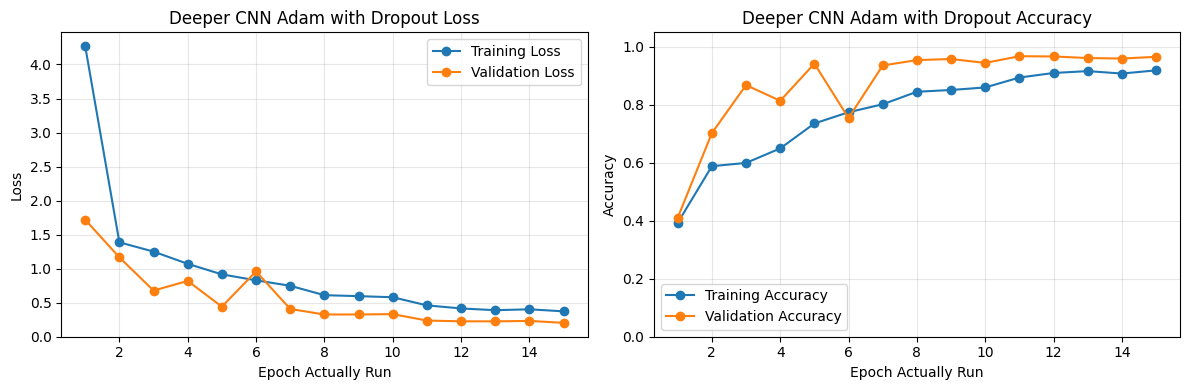

Deeper CNN Adam with Dropout ran for 15 epoch(s) out of the configured maximum of 15.
Deeper CNN Adam Dropout Test Loss: 0.1998
Deeper CNN Adam Dropout Test Accuracy: 0.9702
Class-wise precision, recall, and F1-score:
              precision    recall  f1-score      support
Caution        0.850117  1.000000  0.918987   363.000000
Instructions   1.000000  0.849765  0.918782   426.000000
No Passing     0.998748  0.992537  0.995633   804.000000
OverSpeed      0.992415  0.998728  0.995561   786.000000
accuracy       0.970156  0.970156  0.970156     0.970156
macro avg      0.960320  0.960258  0.957241  2379.000000
weighted avg   0.974201  0.970156  0.970153  2379.000000


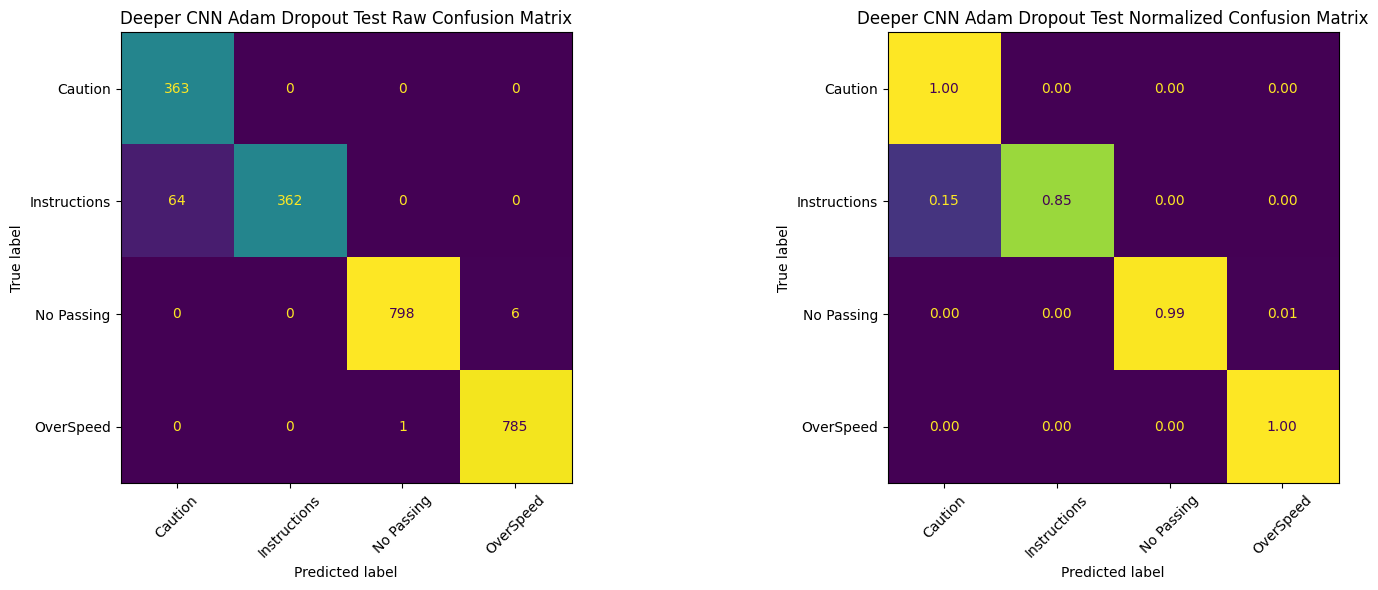

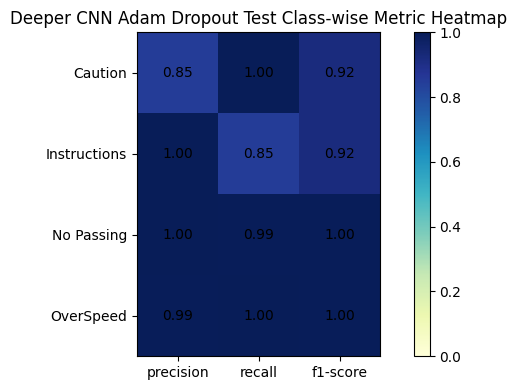

Lowest recall class for Deeper CNN Adam Dropout Test: Instructions (0.8498)
Top confusion pairs for Deeper CNN Adam Dropout Test:
True 'Instructions' predicted as 'Caution': 64 image(s)
True 'No Passing' predicted as 'OverSpeed': 6 image(s)
True 'OverSpeed' predicted as 'No Passing': 1 image(s)
Instruction/Caution note: these signs may share similar shapes, colors, or symbol layouts, which can reduce recall between these classes.


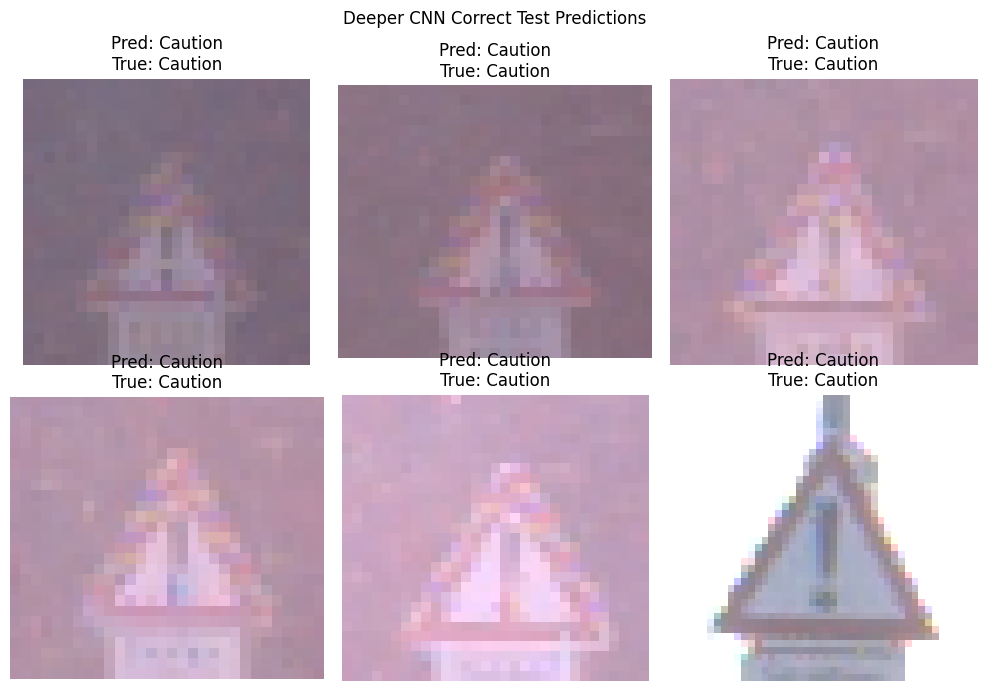

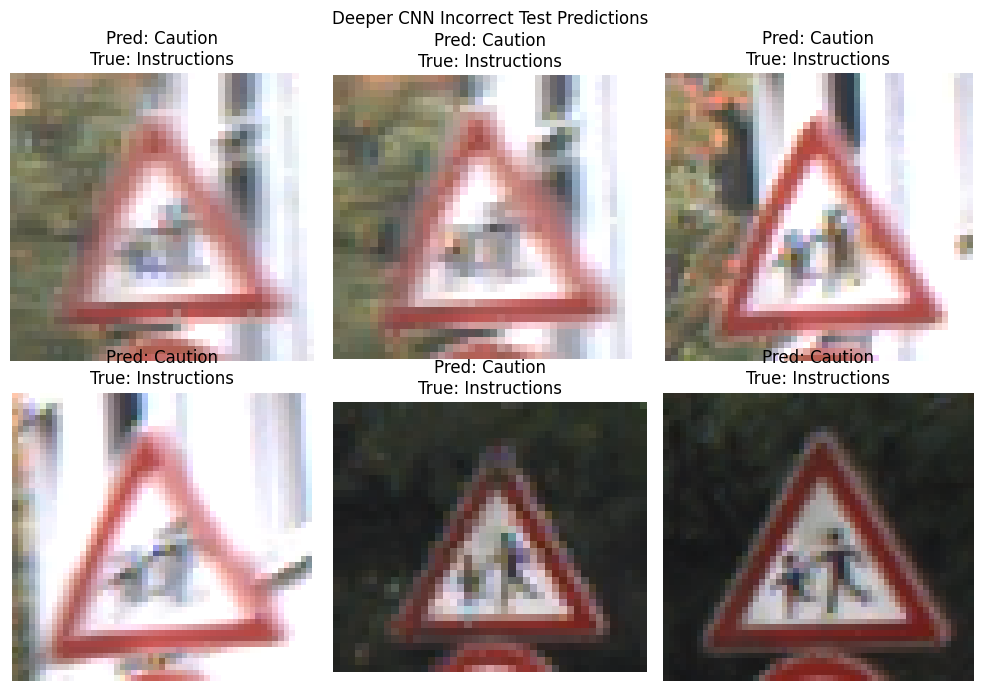

In [15]:
deep_history, deep_time = train_with_timer(
    deep_model,
    train_data,
    val_data,
    "Deeper CNN Adam with Dropout",
    epochs=MAX_EPOCHS
)
print(f"Deeper model training time: {deep_time:.2f} seconds")
plot_history(deep_history, "Deeper CNN Adam with Dropout")

deep_results = evaluate_model(deep_model, test_data, class_names, "Deeper CNN Adam Dropout Test")
analyze_confusions(deep_results, class_names, "Deeper CNN Adam Dropout Test")
display_prediction_examples(test_data, class_names, deep_results['y_true'], deep_results['y_pred'], "Deeper CNN Correct Test Predictions", correct=True)
display_prediction_examples(test_data, class_names, deep_results['y_true'], deep_results['y_pred'], "Deeper CNN Incorrect Test Predictions", correct=False)


**Result explanation:** Compare this model with the baseline using the same `MAX_EPOCHS` and same callbacks. If the deeper model stops earlier, EarlyStopping is showing that extra training was no longer improving validation loss.


## 2.5.4 Experimentation and Comparative Analysis

### 1. Baseline vs Deeper Model Performance

**Question:** How are baseline and deeper performance compared?  
**Answer:** Both models use the same split, same maximum epoch count, and same callback settings. Accuracy, loss, precision, recall, F1-score, confusion matrices, and training time are compared.


Baseline vs Deeper CNN comparison:
Baseline CNN Test: accuracy=0.9975, loss=0.0040, time=921.57s, lowest recall class=Instructions (0.9906)
Deeper CNN Adam Dropout Test: accuracy=0.9702, loss=0.1998, time=1037.25s, lowest recall class=Instructions (0.8498)


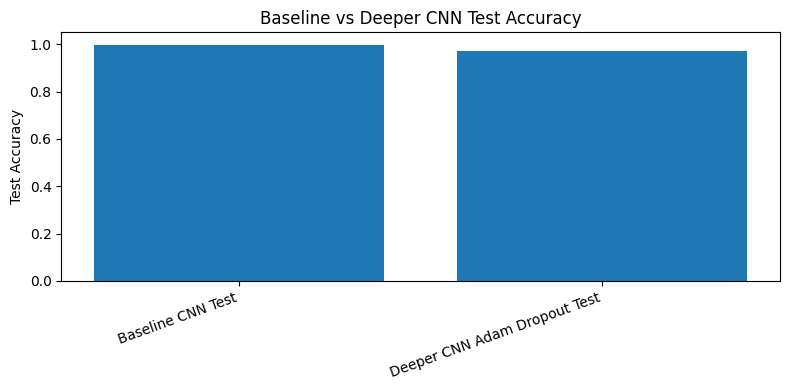

In [16]:
comparison_results = [baseline_results, deep_results]
training_time_lookup = {
    baseline_results['model']: baseline_time,
    deep_results['model']: deep_time
}

print("Baseline vs Deeper CNN comparison:")
for result in comparison_results:
    print(
        f"{result['model']}: accuracy={result['accuracy']:.4f}, "
        f"loss={result['loss']:.4f}, time={training_time_lookup[result['model']]:.2f}s, "
        f"lowest recall class={result['lowest_recall_class']} ({result['lowest_recall_value']:.4f})"
    )

plt.figure(figsize=(8, 4))
plt.bar([r['model'] for r in comparison_results], [r['accuracy'] for r in comparison_results])
plt.ylabel("Test Accuracy")
plt.title("Baseline vs Deeper CNN Test Accuracy")
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()


**Plot/result explanation:** This is a fair comparison because both models had the same maximum epoch budget and callback rules. The deeper model is only better if its test accuracy and class-wise recall/F1 improve enough to justify the extra training time.


### 2. Optimizer Analysis: Adam vs SGD

**Question:** How is SGD compared with Adam?  
**Answer:** The same deeper architecture with Dropout is trained with SGD and Adam using the same maximum epochs and same callbacks.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
348/348 ━━━━━━━━━━━━━━━━━━━━ 85s 213ms/step - accuracy: 0.4183 - loss: 1.8613 - val_accuracy: 0.3443 - val_loss: 2.3390 - learning_rate: 0.0010
Epoch 2/15
348/348 ━━━━━━━━━━━━━━━━━━━━ 65s 187ms/step - accuracy: 0.6666 - loss: 1.1955 - val_accuracy: 0.8331 - val_loss: 0.8759 - learning_rate: 0.0010
Epoch 3/15
348/348 ━━━━━━━━━━━━━━━━━━━━ 64s 184ms/step - accuracy: 0.7427 - loss: 1.0493 - val_accuracy: 0.8382 - val_loss: 0.8087 - learning_rate: 0.0010
Epoch 4/15
348/348 ━━━━━━━━━━━━━━━━━━━━ 65s 186ms/step - accuracy: 0.7764 - loss: 0.9566 - val_accuracy: 0.8747 - val_loss: 0.8364 - learning_rate: 0.0010
Epoch 5/15
348/348 ━━━━━━━━━━━━━━━━━━━━ 64s 183ms/step - accuracy: 0.8107 - loss: 0.8818 - val_accuracy: 0.8558 - val_loss: 0.8012 - learning_rate: 0.0010
Epoch 6/15
348/348 ━━━━━━━━━━━━━━━━━━━━ 65s 187ms/step - accuracy: 0.8294 - loss: 0.8367 - val_accuracy: 0.9290 - val_loss: 0.6047 - learning_rate: 0.0010
Epoch 7/15
348/348 ━━━━━━━━━━━━━━━━━━━━ 68s 195ms/step - accuracy: 0.8

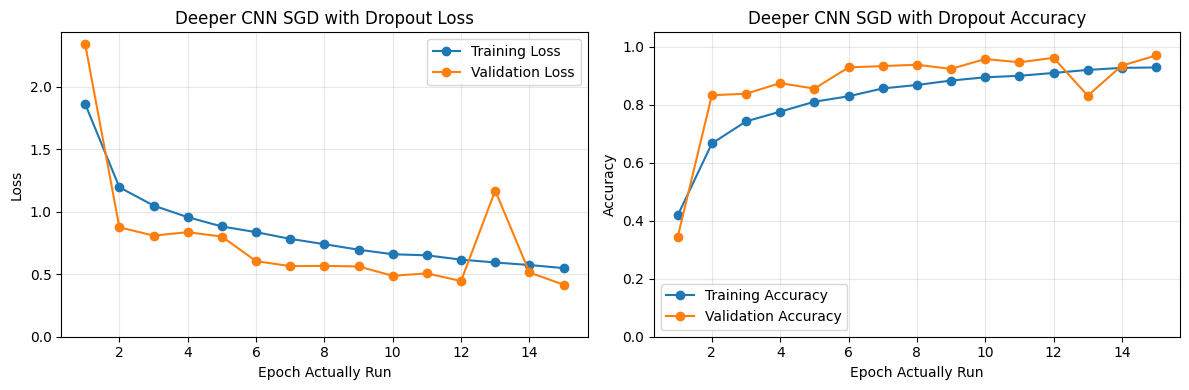

Deeper CNN SGD with Dropout ran for 15 epoch(s) out of the configured maximum of 15.
Deeper CNN SGD Dropout Test Loss: 0.4090
Deeper CNN SGD Dropout Test Accuracy: 0.9723
Class-wise precision, recall, and F1-score:
              precision    recall  f1-score      support
Caution        0.876513  0.997245  0.932990   363.000000
Instructions   1.000000  0.880282  0.936330   426.000000
No Passing     0.998737  0.983831  0.991228   804.000000
OverSpeed      0.982478  0.998728  0.990536   786.000000
accuracy       0.972257  0.972257  0.972257     0.972257
macro avg      0.964432  0.965021  0.962771  2379.000000
weighted avg   0.974942  0.972257  0.972283  2379.000000


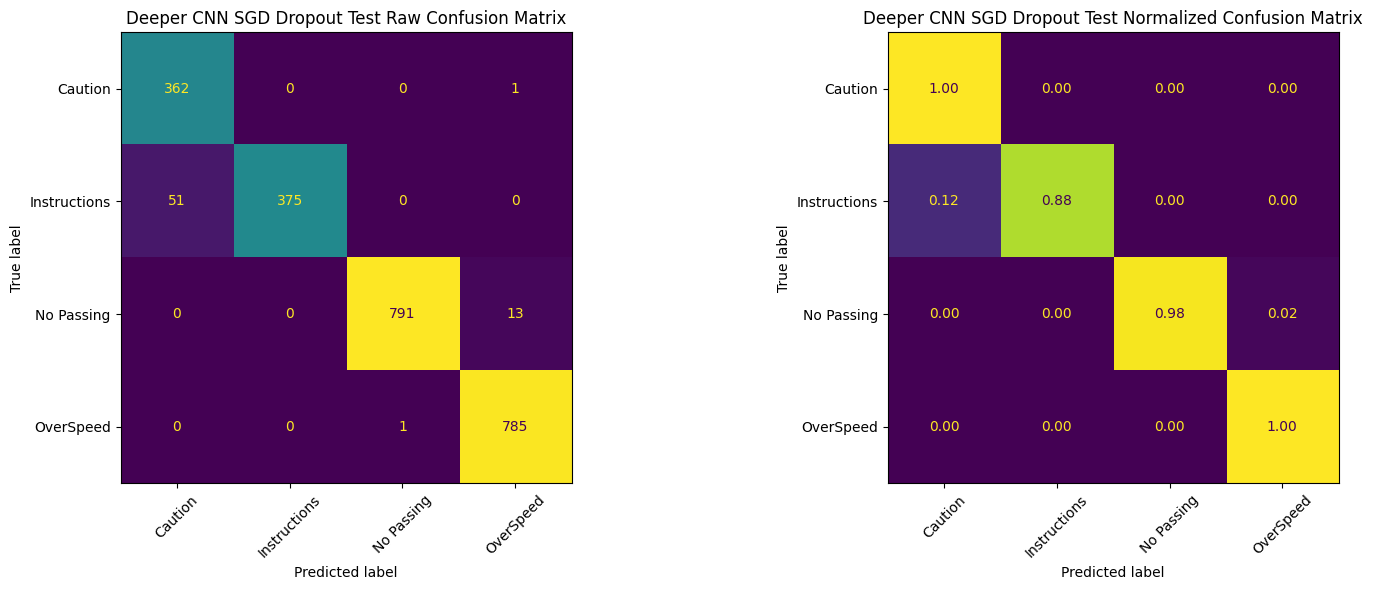

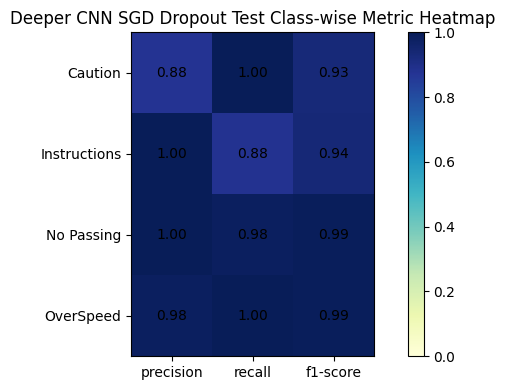

Lowest recall class for Deeper CNN SGD Dropout Test: Instructions (0.8803)
Top confusion pairs for Deeper CNN SGD Dropout Test:
True 'Instructions' predicted as 'Caution': 51 image(s)
True 'No Passing' predicted as 'OverSpeed': 13 image(s)
True 'OverSpeed' predicted as 'No Passing': 1 image(s)
True 'Caution' predicted as 'OverSpeed': 1 image(s)
Instruction/Caution note: these signs may share similar shapes, colors, or symbol layouts, which can reduce recall between these classes.


In [17]:
deep_model_sgd = build_deep_model(num_classes=num_classes, use_dropout=True, optimizer='sgd')
sgd_history, sgd_time = train_with_timer(
    deep_model_sgd,
    train_data,
    val_data,
    "Deeper CNN SGD with Dropout",
    epochs=MAX_EPOCHS
)
print(f"Deeper model with SGD training time: {sgd_time:.2f} seconds")
plot_history(sgd_history, "Deeper CNN SGD with Dropout")
sgd_results = evaluate_model(deep_model_sgd, test_data, class_names, "Deeper CNN SGD Dropout Test")
analyze_confusions(sgd_results, class_names, "Deeper CNN SGD Dropout Test")


**Plot/result explanation:** Adam and SGD are compared with the same architecture and epoch budget. Adam often converges faster, but the final decision should use validation behavior and test class-wise metrics, not training accuracy alone.


### 3. Ablation Study: With Dropout vs Without Dropout

**Question:** How is Dropout evaluated fairly?  
**Answer:** The same deeper architecture is trained once with Dropout and once without Dropout. Both use the same maximum epochs and callbacks. EarlyStopping may stop each at a different actual epoch, which is part of the observation because it shows when validation loss stopped improving.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
348/348 ━━━━━━━━━━━━━━━━━━━━ 81s 207ms/step - accuracy: 0.7370 - loss: 1.8683 - val_accuracy: 0.5599 - val_loss: 2.0111 - learning_rate: 0.0010
Epoch 2/15
348/348 ━━━━━━━━━━━━━━━━━━━━ 66s 191ms/step - accuracy: 0.9156 - loss: 0.6446 - val_accuracy: 0.9529 - val_loss: 0.5198 - learning_rate: 0.0010
Epoch 3/15
348/348 ━━━━━━━━━━━━━━━━━━━━ 67s 191ms/step - accuracy: 0.9357 - loss: 0.5429 - val_accuracy: 0.9639 - val_loss: 0.4055 - learning_rate: 0.0010
Epoch 4/15
348/348 ━━━━━━━━━━━━━━━━━━━━ 66s 189ms/step - accuracy: 0.9585 - loss: 0.4175 - val_accuracy: 0.9861 - val_loss: 0.3055 - learning_rate: 0.0010
Epoch 5/15
348/348 ━━━━━━━━━━━━━━━━━━━━ 67s 191ms/step - accuracy: 0.9676 - loss: 0.3585 - val_accuracy: 0.9483 - val_loss: 0.3896 - learning_rate: 0.0010
Epoch 6/15
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.9661 - loss: 0.3375
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
348/348 ━━━━━━━━━━━━━━━━━━━━ 66s 190ms/step - accuracy: 0.958

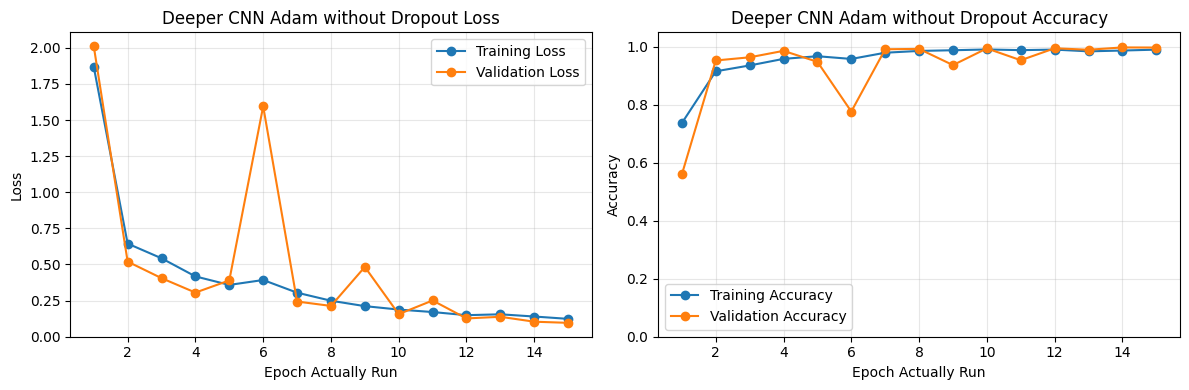

Deeper CNN Adam without Dropout ran for 15 epoch(s) out of the configured maximum of 15.
Deeper CNN Adam No Dropout Test Loss: 0.0975
Deeper CNN Adam No Dropout Test Accuracy: 0.9971
Class-wise precision, recall, and F1-score:
              precision    recall  f1-score      support
Caution        0.989101  1.000000  0.994521   363.000000
Instructions   1.000000  0.992958  0.996466   426.000000
No Passing     1.000000  0.996269  0.998131   804.000000
OverSpeed      0.996193  0.998728  0.997459   786.000000
accuracy       0.997058  0.997058  0.997058     0.997058
macro avg      0.996323  0.996989  0.996644  2379.000000
weighted avg   0.997079  0.997058  0.997060  2379.000000


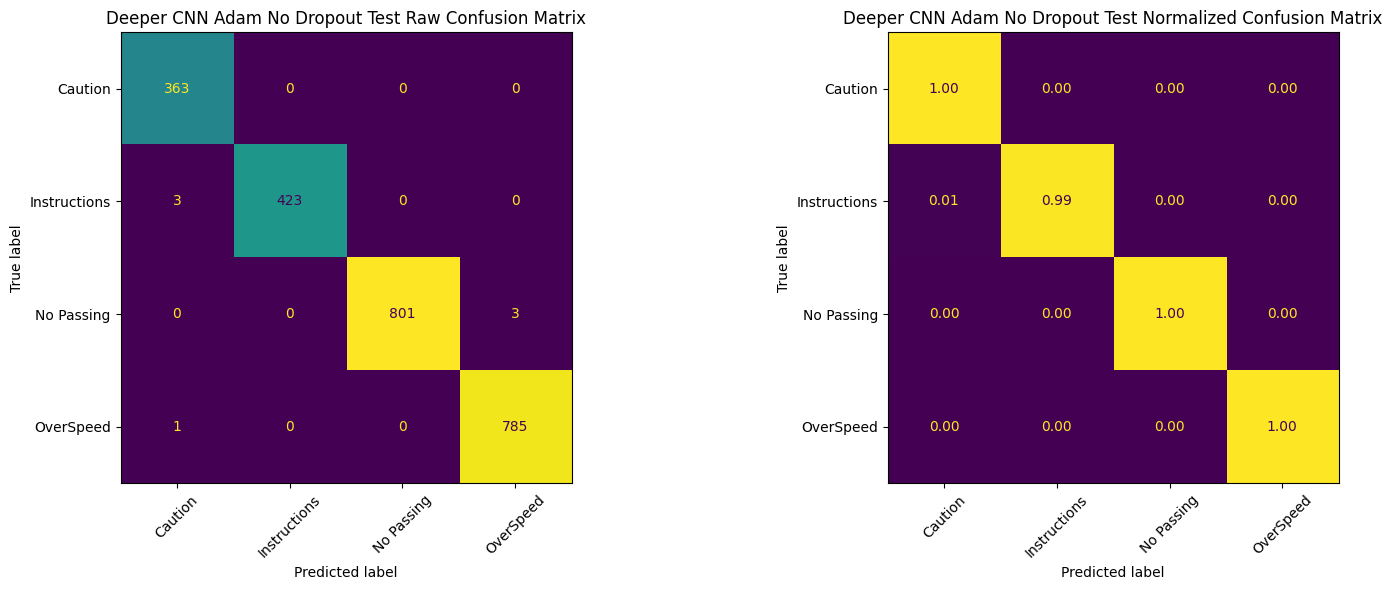

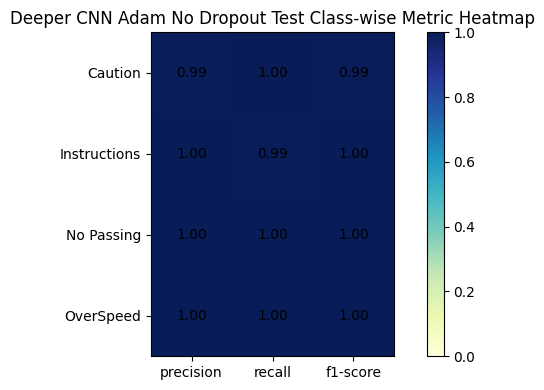

Lowest recall class for Deeper CNN Adam No Dropout Test: Instructions (0.9930)
Top confusion pairs for Deeper CNN Adam No Dropout Test:
True 'No Passing' predicted as 'OverSpeed': 3 image(s)
True 'Instructions' predicted as 'Caution': 3 image(s)
True 'OverSpeed' predicted as 'Caution': 1 image(s)
Instruction/Caution note: these signs may share similar shapes, colors, or symbol layouts, which can reduce recall between these classes.


In [18]:
ablation_model = build_deep_model(num_classes=num_classes, use_dropout=False, optimizer='adam')
ablation_history, ablation_time = train_with_timer(
    ablation_model,
    train_data,
    val_data,
    "Deeper CNN Adam without Dropout",
    epochs=MAX_EPOCHS
)
print(f"Ablation model without Dropout training time: {ablation_time:.2f} seconds")
plot_history(ablation_history, "Deeper CNN Adam without Dropout")
ablation_results = evaluate_model(ablation_model, test_data, class_names, "Deeper CNN Adam No Dropout Test")
analyze_confusions(ablation_results, class_names, "Deeper CNN Adam No Dropout Test")


**Plot/result explanation:** If the no-Dropout model gets higher training accuracy but worse validation/test metrics, it is overfitting. If EarlyStopping stops it earlier, that supports the conclusion that validation loss stopped improving sooner.


# 2.6 Part B: Fine-Tuning a Pre-Trained Model (Transfer Learning)

## 2.6.1 Loading and Adapting VGG16

**Question:** Which pre-trained model is selected and why?  
**Answer:** VGG16 pre-trained on ImageNet is selected based on the tutor's recommendation and because it is a standard CNN architecture studied in deep learning. VGG16 uses stacked `3 x 3` convolutional filters and is commonly used for transfer learning.

**Question:** How is the architecture modified?  
**Answer:** The original ImageNet classification head is removed using `include_top=False`. New dense layers and a final softmax output layer are added for the traffic sign classes.

**Question:** Are layers frozen or fine-tuned?  
**Answer:** First, the VGG16 convolutional base is frozen for feature extraction. Then the final VGG16 block is unfrozen and fine-tuned with a low learning rate.


## 2.6.2 Model Training and Fine-Tuning

**Question:** How are input size differences handled?  
**Answer:** VGG16 uses `224 x 224` inputs, so transfer-learning generators resize images to `224 x 224` and apply the VGG16 preprocessing function.

**Question:** How are output layer differences handled?  
**Answer:** VGG16 trained on ImageNet has a 1000-class output head. This notebook removes that head and adds a new softmax layer with `num_classes` outputs for this dataset.

**Anti-overfitting update:** To avoid unrealistically high transfer-learning results, the VGG16 training generator also uses augmentation, the custom dense head is kept small, Dropout is increased, and only the final convolution layer is fine-tuned.


In [19]:
transfer_train_datagen = ImageDataGenerator(
    preprocessing_function=vgg16_preprocess_input,
    rotation_range=20,
    zoom_range=0.25,
    width_shift_range=0.10,
    height_shift_range=0.10,
    brightness_range=(0.80, 1.20),
    horizontal_flip=True
)
transfer_eval_datagen = ImageDataGenerator(preprocessing_function=vgg16_preprocess_input)

train_data_224 = transfer_train_datagen.flow_from_directory(
    train_dir,
    target_size=TRANSFER_IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_data_224 = transfer_eval_datagen.flow_from_directory(
    val_dir,
    target_size=TRANSFER_IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_data_224 = transfer_eval_datagen.flow_from_directory(
    test_dir,
    target_size=TRANSFER_IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_names_224 = list(train_data_224.class_indices.keys())


Found 11109 images belonging to 4 classes.
Found 2379 images belonging to 4 classes.
Found 2379 images belonging to 4 classes.


**Result explanation:** These generators use VGG16 preprocessing instead of simple rescaling because VGG16 expects ImageNet-style preprocessing.


In [20]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.60)(x)
predictions = Dense(num_classes, activation='softmax')(x)

transfer_model = Model(inputs=base_model.input, outputs=predictions, name="vgg16_transfer")
transfer_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
transfer_model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "vgg16_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,747,780 (56.26 MB)

 Trainable params: 33,092 (129.27 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

**Result explanation:** The VGG16 convolutional base is frozen here, so only the newly added classification layers train during feature extraction.


Epoch 1/8
348/348 ━━━━━━━━━━━━━━━━━━━━ 210s 560ms/step - accuracy: 0.5934 - loss: 1.0048 - val_accuracy: 0.8235 - val_loss: 0.5232 - learning_rate: 0.0010
Epoch 2/8
348/348 ━━━━━━━━━━━━━━━━━━━━ 186s 533ms/step - accuracy: 0.7522 - loss: 0.6029 - val_accuracy: 0.8588 - val_loss: 0.3937 - learning_rate: 0.0010
Epoch 3/8
348/348 ━━━━━━━━━━━━━━━━━━━━ 183s 526ms/step - accuracy: 0.7984 - loss: 0.5095 - val_accuracy: 0.8894 - val_loss: 0.3133 - learning_rate: 0.0010
Epoch 4/8
348/348 ━━━━━━━━━━━━━━━━━━━━ 183s 525ms/step - accuracy: 0.8197 - loss: 0.4519 - val_accuracy: 0.8924 - val_loss: 0.3024 - learning_rate: 0.0010
Epoch 5/8
348/348 ━━━━━━━━━━━━━━━━━━━━ 183s 525ms/step - accuracy: 0.8433 - loss: 0.3980 - val_accuracy: 0.9058 - val_loss: 0.2511 - learning_rate: 0.0010
Epoch 6/8
348/348 ━━━━━━━━━━━━━━━━━━━━ 183s 527ms/step - accuracy: 0.8502 - loss: 0.3763 - val_accuracy: 0.8949 - val_loss: 0.2735 - learning_rate: 0.0010
Epoch 7/8
348/348 ━━━━━━━━━━━━━━━━━━━━ 182s 522ms/step - accuracy: 0.8

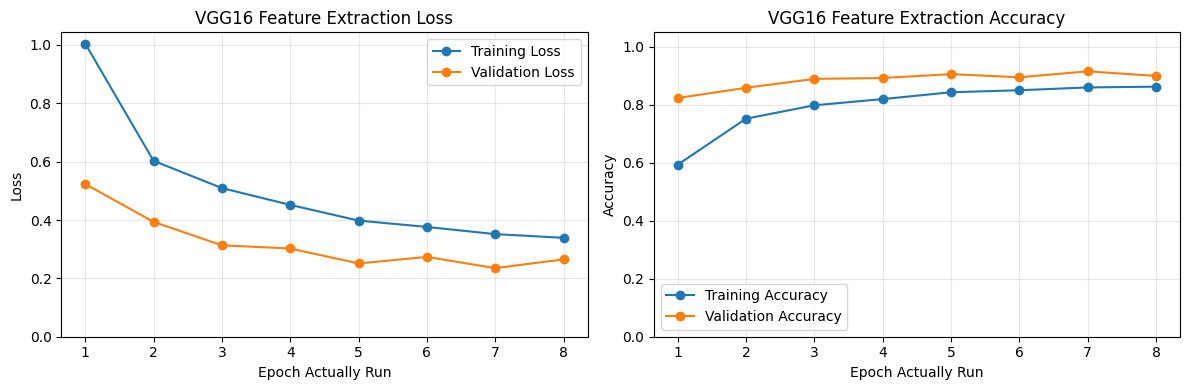

VGG16 Feature Extraction ran for 8 epoch(s) out of the configured maximum of 8.


In [21]:
transfer_history, transfer_time = train_with_timer(
    transfer_model,
    train_data_224,
    val_data_224,
    "VGG16 Feature Extraction",
    epochs=TRANSFER_FEATURE_EPOCHS
)
print(f"VGG16 feature extraction time: {transfer_time:.2f} seconds")
plot_history(transfer_history, "VGG16 Feature Extraction", max_epochs=TRANSFER_FEATURE_EPOCHS)


**Plot/result explanation:** Feature extraction trains only the new head for up to 8 epochs. EarlyStopping prevents overtraining if validation loss stops improving before the phase limit.


Epoch 1/7
348/348 ━━━━━━━━━━━━━━━━━━━━ 190s 533ms/step - accuracy: 0.8995 - loss: 0.2774 - val_accuracy: 0.9197 - val_loss: 0.2655 - learning_rate: 1.0000e-04
Epoch 2/7
348/348 ━━━━━━━━━━━━━━━━━━━━ 184s 528ms/step - accuracy: 0.9545 - loss: 0.1328 - val_accuracy: 0.9823 - val_loss: 0.0472 - learning_rate: 1.0000e-04
Epoch 3/7
348/348 ━━━━━━━━━━━━━━━━━━━━ 184s 528ms/step - accuracy: 0.9676 - loss: 0.1039 - val_accuracy: 0.9823 - val_loss: 0.0489 - learning_rate: 1.0000e-04
Epoch 4/7
348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - accuracy: 0.9768 - loss: 0.0747
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
348/348 ━━━━━━━━━━━━━━━━━━━━ 182s 523ms/step - accuracy: 0.9739 - loss: 0.0818 - val_accuracy: 0.9723 - val_loss: 0.0828 - learning_rate: 1.0000e-04
Epoch 5/7
348/348 ━━━━━━━━━━━━━━━━━━━━ 184s 527ms/step - accuracy: 0.9836 - loss: 0.0458 - val_accuracy: 0.9903 - val_loss: 0.0235 - learning_rate: 5.0000e-05
Epoch 6/7
348/348 ━━━━━━━━━━━━━━━━━━━━ 185s 531ms/st

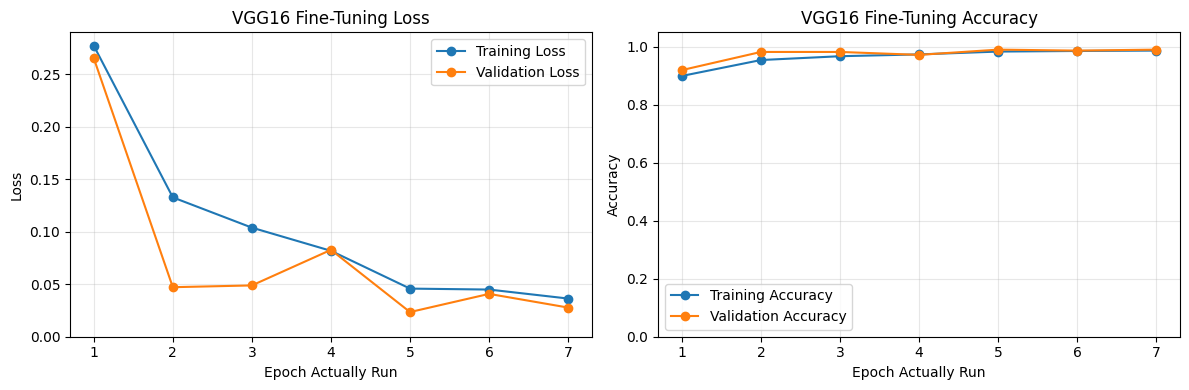

VGG16 Fine-Tuning ran for 7 epoch(s) out of the configured maximum of 7.


In [22]:
for layer in base_model.layers:
    layer.trainable = layer.name == 'block5_conv3'

transfer_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

finetune_history, finetune_time = train_with_timer(
    transfer_model,
    train_data_224,
    val_data_224,
    "VGG16 Fine-Tuning",
    epochs=TRANSFER_FINETUNE_EPOCHS
)
print(f"VGG16 fine-tuning time: {finetune_time:.2f} seconds")
plot_history(finetune_history, "VGG16 Fine-Tuning", max_epochs=TRANSFER_FINETUNE_EPOCHS)


**Plot/result explanation:** Fine-tuning uses a lower learning rate for up to 7 epochs. Together with feature extraction, VGG16 has the same total maximum epoch budget as the other compared models: 15 epochs.


## 2.6.3 Model Evaluation and Prediction

**Question:** How is the fine-tuned model evaluated?  
**Answer:** It is evaluated using the same test metrics as Part A: accuracy, class-wise precision, recall, F1-score, confusion matrix, normalized confusion matrix, and sample predictions.

**Question:** How is transfer learning compared with CNNs from scratch?  
**Answer:** VGG16 test results are compared with baseline CNN, deeper CNN, SGD experiment, and Dropout ablation using the same total maximum epoch budget and EarlyStopping patience.


VGG16 Transfer Test Loss: 0.0213
VGG16 Transfer Test Accuracy: 0.9929
Class-wise precision, recall, and F1-score:
              precision    recall  f1-score      support
Caution        0.978320  0.994490  0.986339   363.000000
Instructions   1.000000  0.983568  0.991716   426.000000
No Passing     0.998748  0.992537  0.995633   804.000000
OverSpeed      0.989899  0.997455  0.993663   786.000000
accuracy       0.992854  0.992854  0.992854     0.992854
macro avg      0.991742  0.992013  0.991838  2379.000000
weighted avg   0.992932  0.992854  0.992863  2379.000000


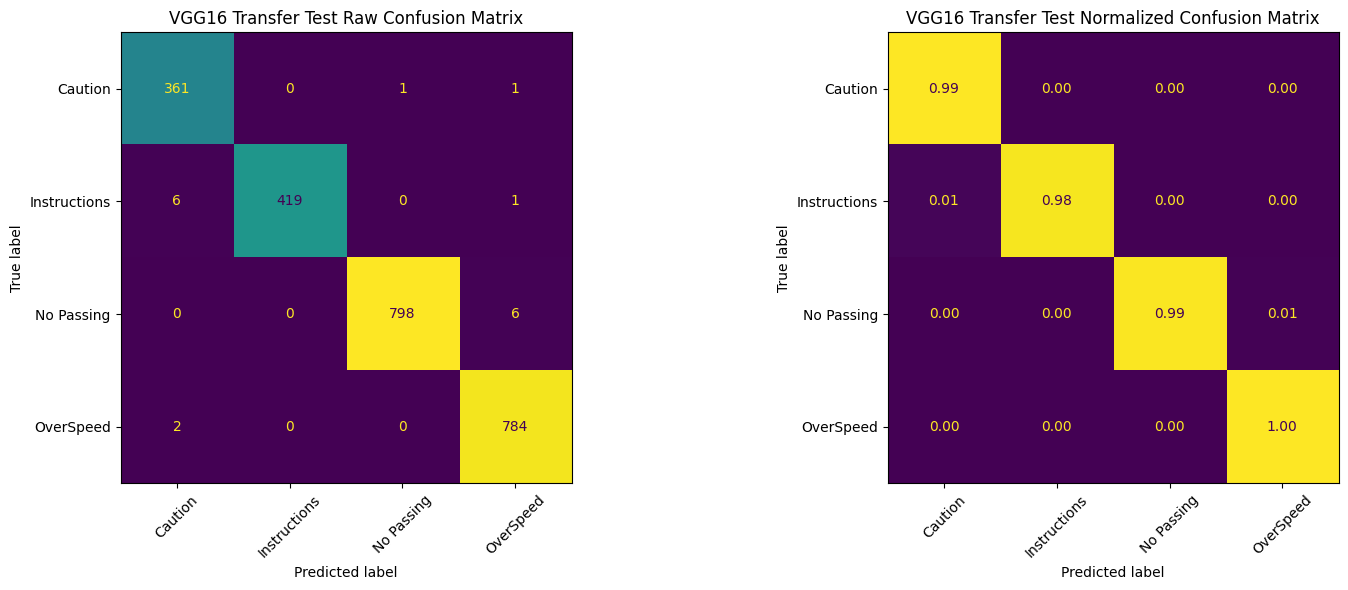

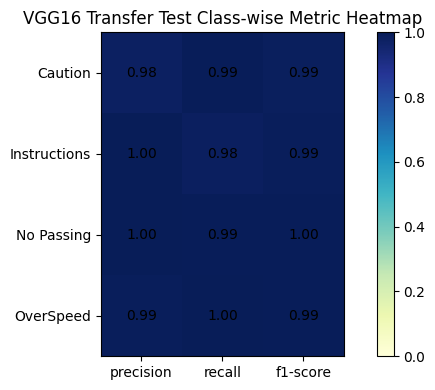

Lowest recall class for VGG16 Transfer Test: Instructions (0.9836)
Top confusion pairs for VGG16 Transfer Test:
True 'No Passing' predicted as 'OverSpeed': 6 image(s)
True 'Instructions' predicted as 'Caution': 6 image(s)
True 'OverSpeed' predicted as 'Caution': 2 image(s)
True 'Instructions' predicted as 'OverSpeed': 1 image(s)
True 'Caution' predicted as 'OverSpeed': 1 image(s)
Instruction/Caution note: these signs may share similar shapes, colors, or symbol layouts, which can reduce recall between these classes.


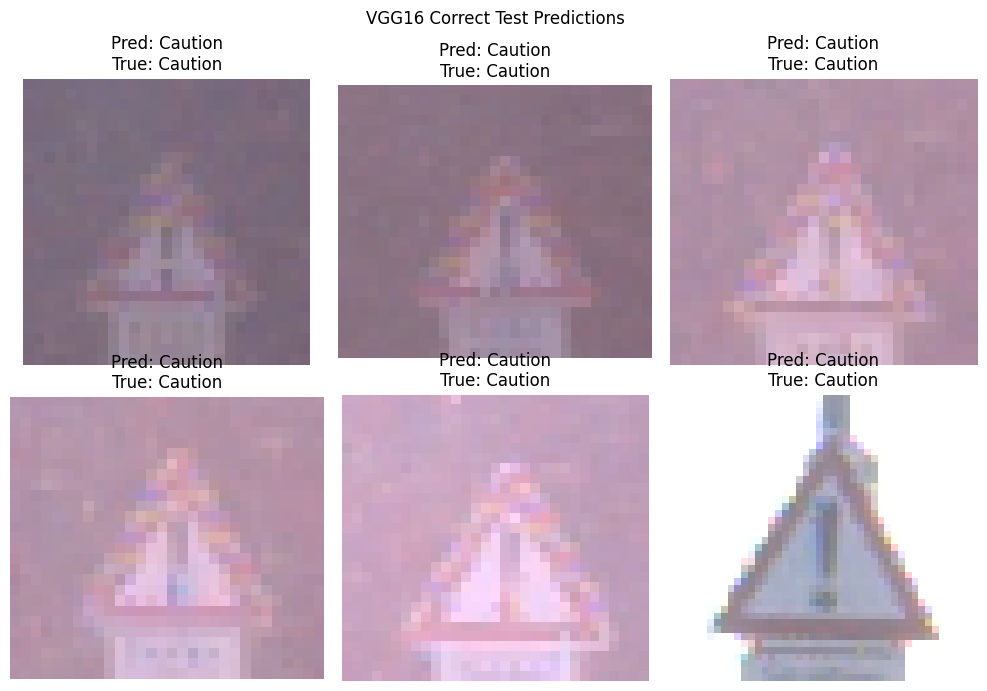

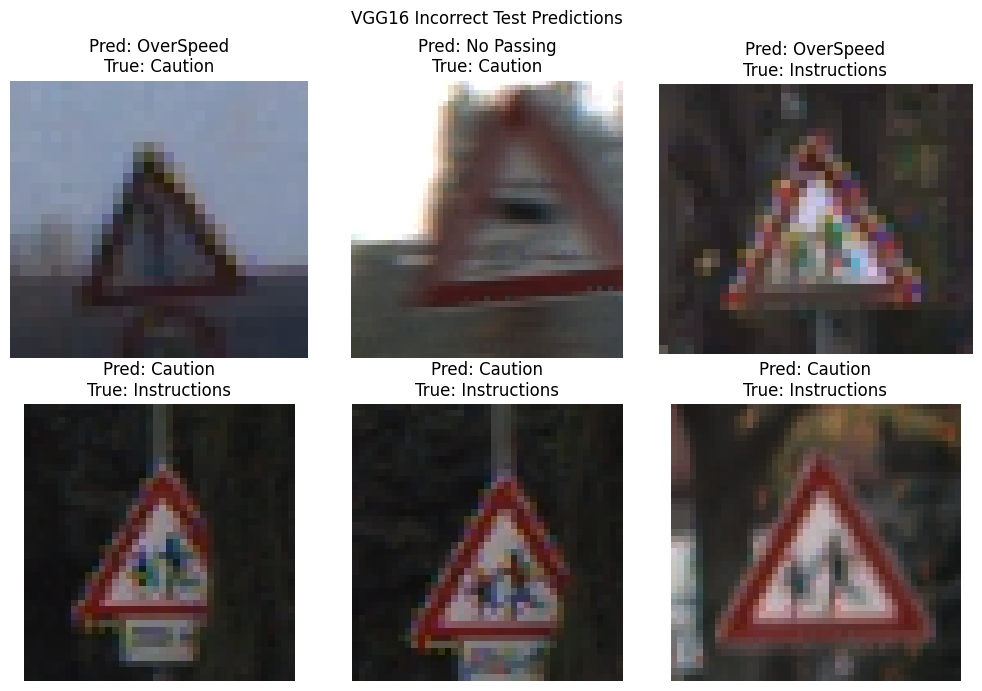

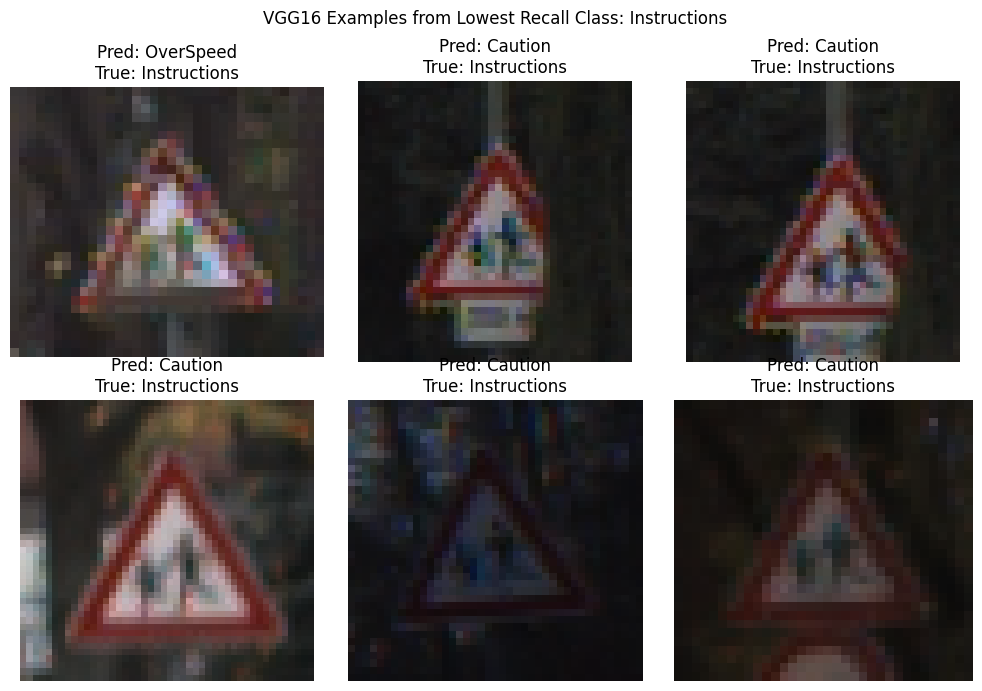

In [23]:
transfer_results = evaluate_model(transfer_model, test_data_224, class_names_224, "VGG16 Transfer Test")
analyze_confusions(transfer_results, class_names_224, "VGG16 Transfer Test")
display_prediction_examples(test_data_224, class_names_224, transfer_results['y_true'], transfer_results['y_pred'], "VGG16 Correct Test Predictions", correct=True)
display_prediction_examples(test_data_224, class_names_224, transfer_results['y_true'], transfer_results['y_pred'], "VGG16 Incorrect Test Predictions", correct=False)
display_prediction_examples(
    test_data_224,
    class_names_224,
    transfer_results['y_true'],
    transfer_results['y_pred'],
    f"VGG16 Examples from Lowest Recall Class: {transfer_results['lowest_recall_class']}",
    correct=False,
    target_class=transfer_results['lowest_recall_class']
)


**Result explanation:** The VGG16 evaluation includes class-wise metrics and both correct and incorrect visualization. If the lowest-recall class is instruction or caution, the confusion-pair output should be used to explain whether those visually similar signs are being mixed.


Final model comparison on held-out test data:
                             model  test_accuracy  test_loss  \
0                Baseline CNN Test       0.997478   0.004007   
1     Deeper CNN Adam Dropout Test       0.970156   0.199825   
2      Deeper CNN SGD Dropout Test       0.972257   0.409020   
3  Deeper CNN Adam No Dropout Test       0.997058   0.097464   
4              VGG16 Transfer Test       0.992854   0.021290   

   training_time_seconds  epochs_actually_run lowest_recall_class  \
0             921.569546                   15        Instructions   
1            1037.246039                   15        Instructions   
2            1001.259223                   15        Instructions   
3            1026.144987                   15        Instructions   
4            2786.333258                   15        Instructions   

   lowest_recall_value  
0             0.990610  
1             0.849765  
2             0.880282  
3             0.992958  
4             0.983568  


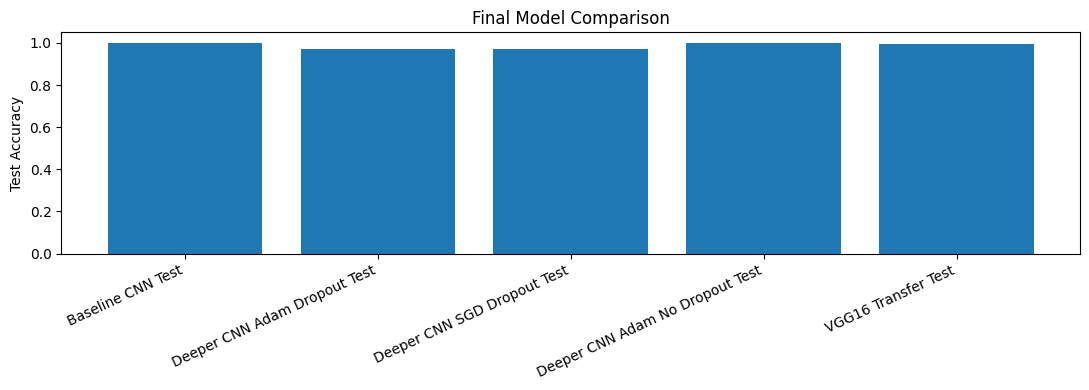

In [24]:
final_results = [
    baseline_results,
    deep_results,
    sgd_results,
    ablation_results,
    transfer_results
]

training_time_lookup = {
    baseline_results['model']: baseline_time,
    deep_results['model']: deep_time,
    sgd_results['model']: sgd_time,
    ablation_results['model']: ablation_time,
    transfer_results['model']: transfer_time + finetune_time
}

epochs_lookup = {
    baseline_results['model']: len(baseline_history.history['loss']),
    deep_results['model']: len(deep_history.history['loss']),
    sgd_results['model']: len(sgd_history.history['loss']),
    ablation_results['model']: len(ablation_history.history['loss']),
    transfer_results['model']: len(transfer_history.history['loss']) + len(finetune_history.history['loss'])
}

summary_rows = []
for result in final_results:
    summary_rows.append({
        "model": result['model'],
        "test_accuracy": result['accuracy'],
        "test_loss": result['loss'],
        "training_time_seconds": training_time_lookup[result['model']],
        "epochs_actually_run": epochs_lookup[result['model']],
        "lowest_recall_class": result['lowest_recall_class'],
        "lowest_recall_value": result['lowest_recall_value']
    })

summary_df = pd.DataFrame(summary_rows)
print("Final model comparison on held-out test data:")
print(summary_df)

plt.figure(figsize=(11, 4))
plt.bar(summary_df['model'], summary_df['test_accuracy'])
plt.ylabel("Test Accuracy")
plt.title("Final Model Comparison")
plt.xticks(rotation=25, ha='right')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()


**Final comparison explanation:** All models use the same total maximum epoch budget and EarlyStopping patience. Baseline, deeper, SGD, and ablation models each have up to 15 epochs. VGG16 uses up to 8 epochs for feature extraction and 7 epochs for fine-tuning, also totaling 15. The actual epochs may differ because EarlyStopping stops models that stop improving. The best model should be selected using test accuracy together with class-wise recall/F1, not accuracy alone.
